# Problem Set III - Question 2

**Course:** QPROG - Quantum Programming

**Students:** Jady Pâmella Barbacena da Silva and Navyashree Suryanarayana Rao Prasanna

**Group:** Group ProblemSet-III-N  

**Assignment:** Implementing the Quantum Fourier Transform in Qiskit

## Environment Setup

Install required packages and import the ClassicalCircuit class.

In [163]:
%pip install qiskit==2.2.3
%pip install qiskit-aer==0.17.2
%pip install matplotlib
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.






In [164]:
# Import required libraries
from qiskit import QuantumCircuit
import os

# Check if we're in the right directory
if os.path.exists("resources/circuit.txt"):
    circuit_file = "resources/circuit.txt"
elif os.path.exists("circuit.txt"):
    circuit_file = "circuit.txt"
else:
    print("Warning: circuit.txt not found. Please ensure it's in the current directory or resources/ folder.")

## ClassicalCircuit Class

Define the ClassicalCircuit class that reads and converts classical circuits to quantum circuits.

In [165]:
class ClassicalCircuit:
    def __init__(self, filename):
        self.n_inputs = 0
        self.n_outputs = 0
        self.n_internal = 0
        self.input_gates = []
        self.output_gates = []
        self.internal_gates = []
        self.gates = []
        self.read(filename)
    
    def read(self, filename):
        """Read circuit definition from file."""
        with open(filename, 'r') as file:
            lines = file.readlines()
        
        self.n_inputs = int(lines[0].strip())
        self.n_outputs = int(lines[1].strip())
        self.n_internal = int(lines[2].strip())
        self.input_gates = list(map(int, lines[3].strip().split()))
        self.output_gates = list(map(int, lines[4].strip().split()))
        self.internal_gates = list(map(int, lines[5].strip().split()))
        
        for line in lines[6:]:
            gate = line.strip().split()
            gate[0] = int(gate[0])
            if gate[1] in ["and", "or", "xor", "nand"]:
                gate[2] = int(gate[2])
                gate[3] = int(gate[3])
            elif gate[1] == "not":
                gate[2] = int(gate[2])
            self.gates.append(gate)
    
    def print(self):
        """Print circuit information."""
        print(f"n_inputs: {self.n_inputs}")
        print(f"n_outputs: {self.n_outputs}")
        print(f"n_internal: {self.n_internal}")
        print(f"Input Gates: {self.input_gates}")
        print(f"Output Gates: {self.output_gates}")
        print(f"Internal Gates: {self.internal_gates}")
        print("Gates:")
        for gate in self.gates:
            print(gate)
        print()

## Task 2.3: Implement convert_step_1

Convert classical gates using ancilla qubits initialized to |0⟩.

In [166]:
def convert_step_1(self, quantumCircuit):
    """
    Convert classical gates to quantum gates using ancilla qubits at |0⟩.
    """
    
    for gate in self.gates:
        output = gate[0]
        gate_type = gate[1]
        
        if gate_type == "not":
            input1 = gate[2]
            # First X to flip |0⟩ to |1⟩
            quantumCircuit.x(output)
            # Then CNOT to compute NOT: |x⟩|1⟩ → |x⟩|1⊕x⟩ = |x⟩|NOT x⟩
            quantumCircuit.cx(input1, output)
        
        elif gate_type == "and":
            input1 = gate[2]
            input2 = gate[3]
            quantumCircuit.ccx(input1, input2, output)
        
        elif gate_type == "or":
            input1 = gate[2]
            input2 = gate[3]
            quantumCircuit.x(input1)
            quantumCircuit.x(input2)
            quantumCircuit.ccx(input1, input2, output)
            quantumCircuit.x(input1)
            quantumCircuit.x(input2)
            quantumCircuit.x(output)
        
        elif gate_type == "xor":
            input1 = gate[2]
            input2 = gate[3]
            quantumCircuit.cx(input1, output)
            quantumCircuit.cx(input2, output)
        
        elif gate_type == "nand":
            input1 = gate[2]
            input2 = gate[3]
            quantumCircuit.ccx(input1, input2, output)
            quantumCircuit.x(output)
        
        quantumCircuit.barrier()

# Add method to ClassicalCircuit class
ClassicalCircuit.convert_step_1 = convert_step_1

## Task 2.4: Implement convert_step_2

Apply gates from Step 1 in reverse order.

In [167]:
def convert_step_2(self, quantumCircuit):
    """
    Apply gates from convert_step_1 in reverse order.
    """

    # Apply gates in reverse order
    for gate in reversed(self.gates):
        output = gate[0]
        gate_type = gate[1]
        
        if gate_type == "not":
            input1 = gate[2]
            # Apply in reverse: CX first, then X
            quantumCircuit.cx(input1, output)
            quantumCircuit.x(output)
        
        elif gate_type == "and":
            input1 = gate[2]
            input2 = gate[3]
            quantumCircuit.ccx(input1, input2, output)
        
        elif gate_type == "or":
            input1 = gate[2]
            input2 = gate[3]
            quantumCircuit.x(output)
            quantumCircuit.x(input1)
            quantumCircuit.x(input2)
            quantumCircuit.ccx(input1, input2, output)
            quantumCircuit.x(input1)
            quantumCircuit.x(input2)
        
        elif gate_type == "xor":
            input1 = gate[2]
            input2 = gate[3]
            quantumCircuit.cx(input2, output)
            quantumCircuit.cx(input1, output)
        
        elif gate_type == "nand":
            input1 = gate[2]
            input2 = gate[3]
            quantumCircuit.x(output)
            quantumCircuit.ccx(input1, input2, output)
        
        quantumCircuit.barrier()

# Add method to ClassicalCircuit class
ClassicalCircuit.convert_step_2 = convert_step_2

## Task 2.5: Implement convert

Complete conversion with output preservation and uncompute.

In [168]:
def convert(self, quantumCircuit):
    """
    Implements the full Uf transformation: |x>|0>|0> -> |x>|f(x)>|0>
    Circuit has n_inputs + 2*n_outputs + n_internal qubits.
    """
    # Apply the same circuit as convert_step_1 
    self.convert_step_1(quantumCircuit)
    
    # Copy classical output bits to the fresh output register
    ancilla_offset = self.n_inputs + self.n_outputs + self.n_internal
    for i, output_gate in enumerate(self.output_gates):
        quantumCircuit.cx(output_gate, ancilla_offset + i)
    quantumCircuit.barrier()
    
    # Uncompute the entire auxiliary register 
    self.convert_step_2(quantumCircuit)

# Add method to ClassicalCircuit class
ClassicalCircuit.convert = convert

## Task 2.6: Implement Controlled Versions

Implement controlled versions where all operations are controlled by qubit i.

In [169]:
def convert_contr_step_1(self, quantumCircuit, control):
    """
    Controlled version of convert_step_1.
    Every elementary gate is controlled by qubit `control`.
    """
    for gate in self.gates:
        output = gate[0]
        gate_type = gate[1]

        if gate_type == "not":
            inp = gate[2]
            # Controlled X on `output`
            quantumCircuit.cx(control, output)
            # Controlled CNOT becomes CCX with extra control
            quantumCircuit.ccx(control, inp, output)

        elif gate_type == "and":
            inp1 = gate[2]
            inp2 = gate[3]
            # Controlled CCX -> 3 controlled X
            quantumCircuit.mcx([control, inp1, inp2], output)

        elif gate_type == "or":
            inp1 = gate[2]
            inp2 = gate[3]
            # Same decomposition as in convert_step_1, but every X and CCX is controlled
            quantumCircuit.cx(control, inp1)
            quantumCircuit.cx(control, inp2)
            quantumCircuit.mcx([control, inp1, inp2], output)
            quantumCircuit.cx(control, inp1)
            quantumCircuit.cx(control, inp2)
            quantumCircuit.cx(control, output)

        elif gate_type == "xor":
            inp1 = gate[2]
            inp2 = gate[3]
            quantumCircuit.ccx(control, inp1, output)
            quantumCircuit.ccx(control, inp2, output)

        elif gate_type == "nand":
            inp1 = gate[2]
            inp2 = gate[3]
            quantumCircuit.mcx([control, inp1, inp2], output)
            quantumCircuit.cx(control, output)

        quantumCircuit.barrier()

def convert_contr_step_2(self, quantumCircuit, control):
    """
    Controlled version of convert_step_2.
    Applies the controlled gates in exact reverse order.
    """
    for gate in reversed(self.gates):
        output = gate[0]
        gate_type = gate[1]

        if gate_type == "not":
            inp = gate[2]
            # Inverse of step 1: CCX first, then CX
            quantumCircuit.ccx(control, inp, output)
            quantumCircuit.cx(control, output)

        elif gate_type == "and":
            inp1 = gate[2]
            inp2 = gate[3]
            quantumCircuit.mcx([control, inp1, inp2], output)

        elif gate_type == "or":
            inp1 = gate[2]
            inp2 = gate[3]
            # Reverse of step 1 sequence
            quantumCircuit.cx(control, output)
            quantumCircuit.cx(control, inp2)
            quantumCircuit.cx(control, inp1)
            quantumCircuit.mcx([control, inp1, inp2], output)
            quantumCircuit.cx(control, inp2)
            quantumCircuit.cx(control, inp1)

        elif gate_type == "xor":
            inp1 = gate[2]
            inp2 = gate[3]
            quantumCircuit.ccx(control, inp2, output)
            quantumCircuit.ccx(control, inp1, output)

        elif gate_type == "nand":
            inp1 = gate[2]
            inp2 = gate[3]
            quantumCircuit.cx(control, output)
            quantumCircuit.mcx([control, inp1, inp2], output)

        quantumCircuit.barrier()

def convert_contr(self, quantumCircuit, control):
    """
    Controlled version of convert.
    Control qubit `control` must be different from all qubits used by convert.
    """
    # Step 1: controlled version of compute
    self.convert_contr_step_1(quantumCircuit, control)
    quantumCircuit.barrier()

    # Step 2: controlled copy of output bits to the fresh output register
    ancilla_offset = self.n_inputs + self.n_outputs + self.n_internal
    for i, out_gate in enumerate(self.output_gates):
        quantumCircuit.ccx(control, out_gate, ancilla_offset + i)
    quantumCircuit.barrier()

    # Step 3: controlled uncompute of the whole auxiliary register
    self.convert_contr_step_2(quantumCircuit, control)
    quantumCircuit.barrier()

# Add methods to ClassicalCircuit class
ClassicalCircuit.convert_contr_step_1 = convert_contr_step_1
ClassicalCircuit.convert_contr_step_2 = convert_contr_step_2
ClassicalCircuit.convert_contr = convert_contr

## Test Tasks 2.3, 2.4 and 2.5: Conversions

Test all methods with the provided circuit.txt file.

In [170]:
# Load and print circuit
cc = ClassicalCircuit(circuit_file)
cc.print()

n_inputs: 3
n_outputs: 2
n_internal: 2
Input Gates: [0, 1, 2]
Output Gates: [3, 4]
Internal Gates: [5, 6]
Gates:
[5, 'and', 0, 1]
[3, 'not', 5]
[6, 'not', 2]
[4, 'and', 5, 6]



2.3 Step 1 - Basic conversion with ancilla at |0⟩ (Figure 5):
           ░            ░            ░       ░ 
q_0: ──■───░────────────░────────────░───────░─
       │   ░            ░            ░       ░ 
q_1: ──■───░────────────░────────────░───────░─
       │   ░            ░            ░       ░ 
q_2: ──┼───░────────────░────────■───░───────░─
       │   ░ ┌───┐┌───┐ ░        │   ░       ░ 
q_3: ──┼───░─┤ X ├┤ X ├─░────────┼───░───────░─
       │   ░ └───┘└─┬─┘ ░        │   ░ ┌───┐ ░ 
q_4: ──┼───░────────┼───░────────┼───░─┤ X ├─░─
     ┌─┴─┐ ░        │   ░        │   ░ └─┬─┘ ░ 
q_5: ┤ X ├─░────────■───░────────┼───░───■───░─
     └───┘ ░            ░ ┌───┐┌─┴─┐ ░   │   ░ 
q_6: ──────░────────────░─┤ X ├┤ X ├─░───■───░─
           ░            ░ └───┘└───┘ ░       ░ 



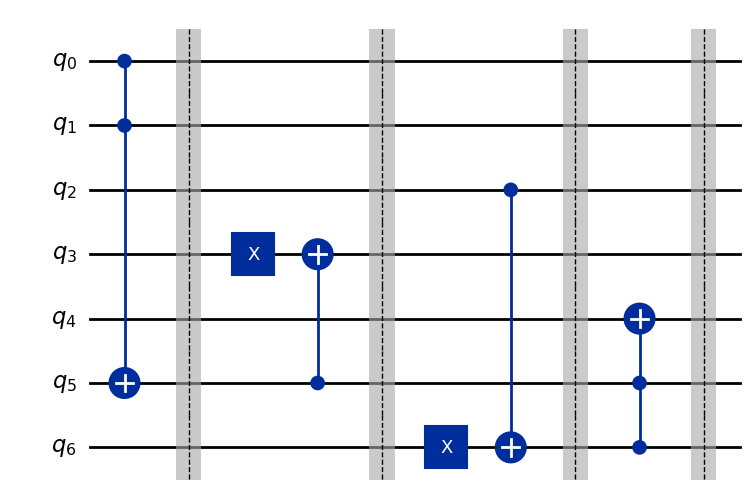

In [171]:
# Test convert_step_1
n_wires = cc.n_inputs + cc.n_outputs + cc.n_internal
qc1 = QuantumCircuit(n_wires, 0)
cc.convert_step_1(qc1)
print("2.3 Step 1 - Basic conversion with ancilla at |0⟩ (Figure 5):")
print(qc1)
print()
qc1.draw('mpl')

2.4 Step 2 - Convert with uncompute of internal qubits (Figure 6):
           ░            ░            ░       ░ 
q_0: ──────░────────────░────────────░───■───░─
           ░            ░            ░   │   ░ 
q_1: ──────░────────────░────────────░───■───░─
           ░            ░            ░   │   ░ 
q_2: ──────░───■────────░────────────░───┼───░─
           ░   │        ░ ┌───┐┌───┐ ░   │   ░ 
q_3: ──────░───┼────────░─┤ X ├┤ X ├─░───┼───░─
     ┌───┐ ░   │        ░ └─┬─┘└───┘ ░   │   ░ 
q_4: ┤ X ├─░───┼────────░───┼────────░───┼───░─
     └─┬─┘ ░   │        ░   │        ░ ┌─┴─┐ ░ 
q_5: ──■───░───┼────────░───■────────░─┤ X ├─░─
       │   ░ ┌─┴─┐┌───┐ ░            ░ └───┘ ░ 
q_6: ──■───░─┤ X ├┤ X ├─░────────────░───────░─
           ░ └───┘└───┘ ░            ░       ░ 



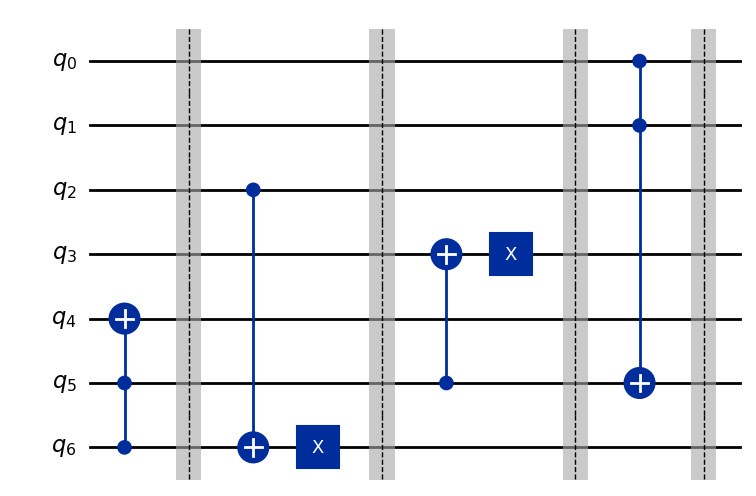

In [172]:
# Test convert_step_2
n_wires = cc.n_inputs + cc.n_outputs + cc.n_internal
qc2 = QuantumCircuit(n_wires, 0)
cc.convert_step_2(qc2)
print("2.4 Step 2 - Convert with uncompute of internal qubits (Figure 6):")
print(qc2)
print()
qc2.draw('mpl')

2.5 Step 3 - Complete Convert with output preservation and uncompute (Figure 7):
           ░            ░            ░       ░            ░       ░           »
q_0: ──■───░────────────░────────────░───────░────────────░───────░───────────»
       │   ░            ░            ░       ░            ░       ░           »
q_1: ──■───░────────────░────────────░───────░────────────░───────░───────────»
       │   ░            ░            ░       ░            ░       ░           »
q_2: ──┼───░────────────░────────■───░───────░────────────░───────░───■───────»
       │   ░ ┌───┐┌───┐ ░        │   ░       ░            ░       ░   │       »
q_3: ──┼───░─┤ X ├┤ X ├─░────────┼───░───────░───■────────░───────░───┼───────»
       │   ░ └───┘└─┬─┘ ░        │   ░ ┌───┐ ░   │        ░ ┌───┐ ░   │       »
q_4: ──┼───░────────┼───░────────┼───░─┤ X ├─░───┼────■───░─┤ X ├─░───┼───────»
     ┌─┴─┐ ░        │   ░        │   ░ └─┬─┘ ░   │    │   ░ └─┬─┘ ░   │       »
q_5: ┤ X ├─░────────■───░────────┼───░─

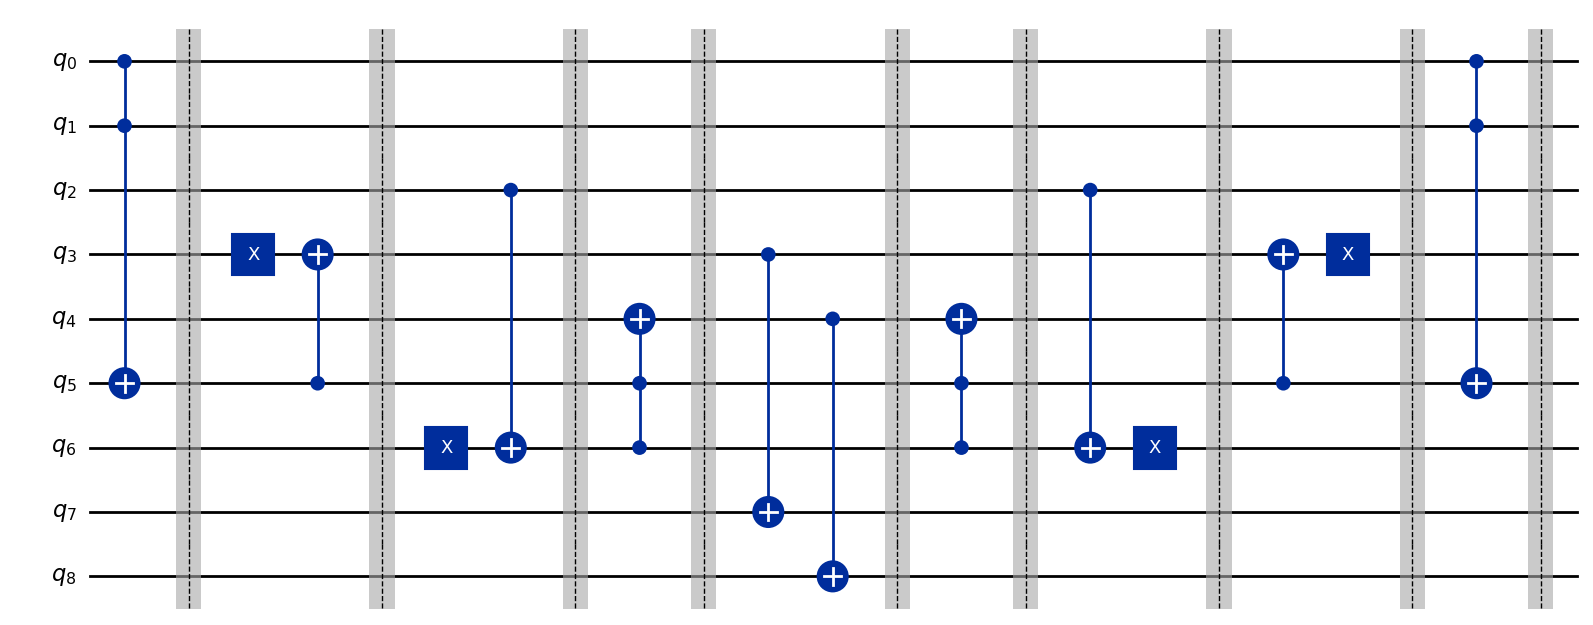

In [173]:
# Test convert (complete)
n_wires = cc.n_inputs + 2*cc.n_outputs + cc.n_internal
qc3 = QuantumCircuit(n_wires, 0)
cc.convert(qc3)
print("2.5 Step 3 - Complete Convert with output preservation and uncompute (Figure 7):")
print(qc3)
print()
qc3.draw('mpl')

## Test Task 2.6: Controlled Versions

Test the controlled conversion methods.

2.6 - Controlled Uf (Figure 8):
Control qubit: q9
           ░            ░            ░       ░  ░            ░       ░      »
q_0: ──■───░────────────░────────────░───────░──░────────────░───────░──────»
       │   ░            ░            ░       ░  ░            ░       ░      »
q_1: ──■───░────────────░────────────░───────░──░────────────░───────░──────»
       │   ░            ░            ░       ░  ░            ░       ░      »
q_2: ──┼───░────────────░────────■───░───────░──░────────────░───────░───■──»
       │   ░ ┌───┐┌───┐ ░        │   ░       ░  ░            ░       ░   │  »
q_3: ──┼───░─┤ X ├┤ X ├─░────────┼───░───────░──░───■────────░───────░───┼──»
       │   ░ └─┬─┘└─┬─┘ ░        │   ░ ┌───┐ ░  ░   │        ░ ┌───┐ ░   │  »
q_4: ──┼───░───┼────┼───░────────┼───░─┤ X ├─░──░───┼────■───░─┤ X ├─░───┼──»
     ┌─┴─┐ ░   │    │   ░        │   ░ └─┬─┘ ░  ░   │    │   ░ └─┬─┘ ░   │  »
q_5: ┤ X ├─░───┼────■───░────────┼───░───■───░──░───┼────┼───░───■───░───┼──»
     └─┬─┘ ░  

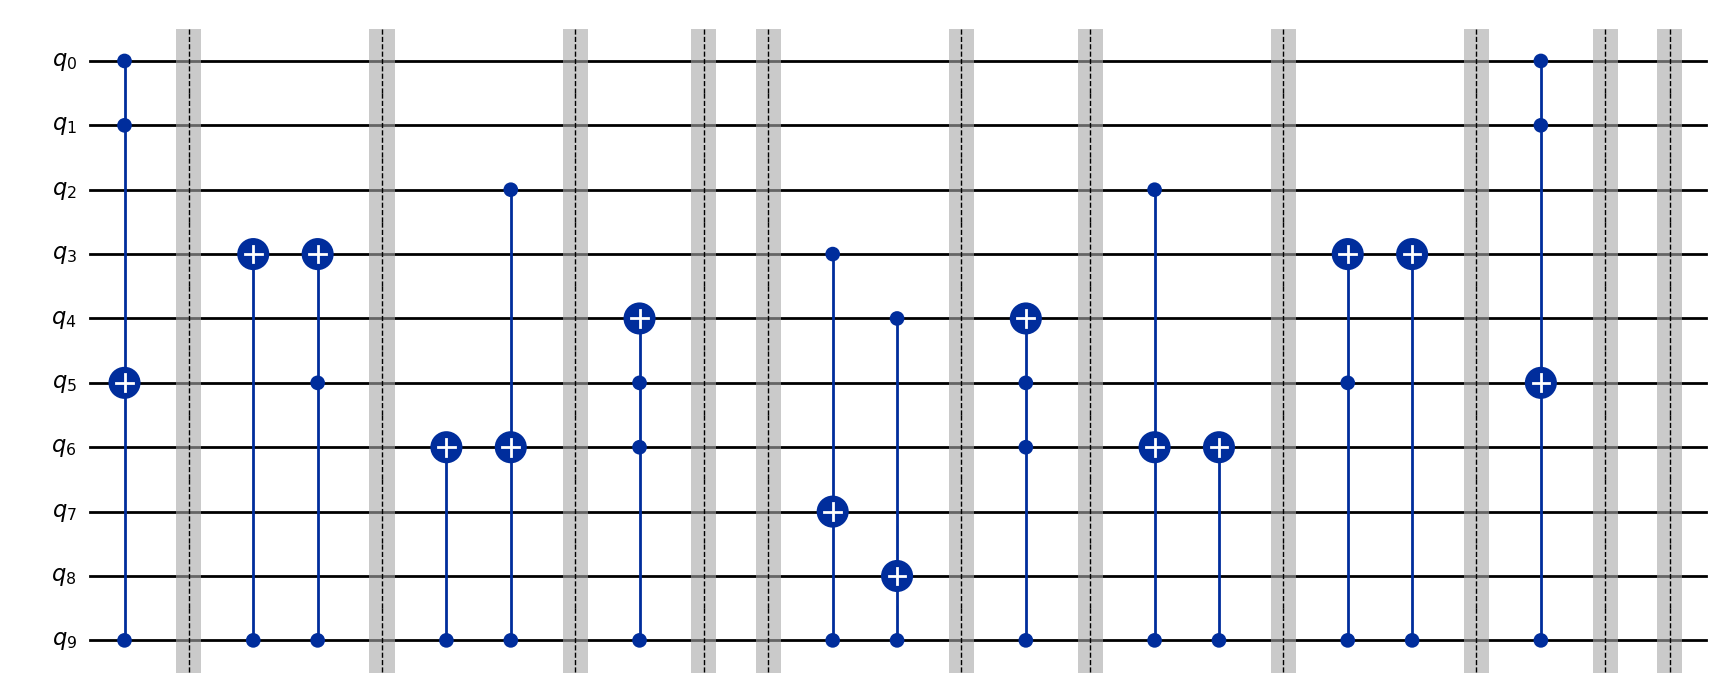

In [174]:
# Test controlled Uf 
# Control qubit is at position 9 (after all circuit qubits)
n_wires_contr = cc.n_inputs + 2*cc.n_outputs + cc.n_internal + 1  # +1 for control qubit
control_qubit = 9  # q9 as shown in Figure 8

qc_contr = QuantumCircuit(n_wires_contr, 0)

# Apply controlled Uf 
cc.convert_contr(qc_contr, control_qubit)

print("2.6 - Controlled Uf (Figure 8):")
print(f"Control qubit: q{control_qubit}")
print(qc_contr)
print()
qc_contr.draw('mpl')

In [175]:
# Test controlled operations with control=0 vs control=1
print("Testing controlled Uf behavior:\n")

# Test 1: Control = |0> (operations should NOT be applied)
print("Test 1: Control qubit = |0>")
qc_test1 = QuantumCircuit(n_wires_contr, cc.n_outputs)
qc_test1.x(0)  # Set input to |1>
qc_test1.x(1)  # Set input to |1>
# Control qubit stays at |0>
cc.convert_contr(qc_test1, control_qubit)

# Measure outputs
ancilla_offset = cc.n_inputs + cc.n_outputs + cc.n_internal
for i in range(cc.n_outputs):
    qc_test1.measure(ancilla_offset + i, i)

result1 = simulator.run(transpile(qc_test1, simulator), shots=1).result()
output1 = list(result1.get_counts().keys())[0]
print(f"  Input: |11>, Control: |0> -> Output: {output1} (should be 00 - no computation)")

# Test 2: Control = |1> (operations SHOULD be applied)
print("\nTest 2: Control qubit = |1>")
qc_test2 = QuantumCircuit(n_wires_contr, cc.n_outputs)
qc_test2.x(0)  # Set input to |1>
qc_test2.x(1)  # Set input to |1>
qc_test2.x(control_qubit)  # Set control to |1>
cc.convert_contr(qc_test2, control_qubit)

# Measure outputs
for i in range(cc.n_outputs):
    qc_test2.measure(ancilla_offset + i, i)

result2 = simulator.run(transpile(qc_test2, simulator), shots=1).result()
output2 = list(result2.get_counts().keys())[0]
print(f"  Input: |11>, Control: |1> -> Output: {output2} (should be 10 - computation done)")

Testing controlled Uf behavior:

Test 1: Control qubit = |0>
  Input: |11>, Control: |0> -> Output: 00 (should be 00 - no computation)

Test 2: Control qubit = |1>
  Input: |11>, Control: |1> -> Output: 10 (should be 10 - computation done)


## Task 2.7: Bonus - Extended Gate Set

Implement additional classical gates: OR, XOR, and NAND using quantum gates.

**Gate Implementations:**
- **OR**: Use De Morgan's law: `OR(a,b) = NOT(AND(NOT(a), NOT(b)))`
- **XOR**: Use two CNOT gates: `XOR(a,b) = a ⊕ b`
- **NAND**: Apply NOT after AND: `NAND(a,b) = NOT(AND(a,b))`

Task 2.7 - Bonus: Testing Extended Gate Set

Testing OR Gate
     ┌───┐┌───┐     ┌───┐   
q_0: ┤ X ├┤ X ├──■──┤ X ├───
     ├───┤├───┤  │  ├───┤   
q_1: ┤ X ├┤ X ├──■──┤ X ├───
     └───┘└───┘┌─┴─┐├───┤┌─┐
q_2: ──────────┤ X ├┤ X ├┤M├
               └───┘└───┘└╥┘
c: 1/═════════════════════╩═
                          0 

OR(1,1) = 1 (expected: 1)



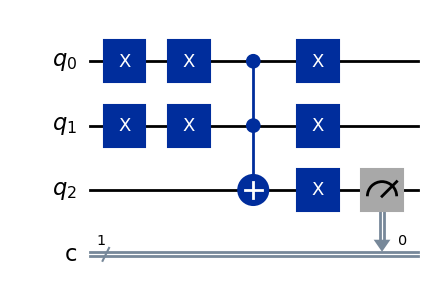

In [176]:
# Test OR gate implementation
print("Task 2.7 - Bonus: Testing Extended Gate Set\n")
print("=" * 50)
print("Testing OR Gate")
print("=" * 50)

qc_or = QuantumCircuit(3, 1)
qc_or.x(0)  # Input a = 1
qc_or.x(1)  # Input b = 1

# OR implementation: OR(a,b) using De Morgan's law
# First flip inputs
qc_or.x(0)
qc_or.x(1)
# Apply Toffoli (AND of flipped inputs)
qc_or.ccx(0, 1, 2)
# Flip inputs back
qc_or.x(0)
qc_or.x(1)
# Flip output to get OR
qc_or.x(2)

qc_or.measure(2, 0)
print(qc_or)
print()

result_or = simulator.run(transpile(qc_or, simulator), shots=1).result()
print(f"OR(1,1) = {list(result_or.get_counts().keys())[0]} (expected: 1)")
print()
qc_or.draw('mpl')

Testing XOR Gate
     ┌───┐             
q_0: ┤ X ├──■──────────
     ├───┤  │          
q_1: ┤ X ├──┼────■─────
     └───┘┌─┴─┐┌─┴─┐┌─┐
q_2: ─────┤ X ├┤ X ├┤M├
          └───┘└───┘└╥┘
c: 1/════════════════╩═
                     0 

XOR(1,1) = 0 (expected: 0)



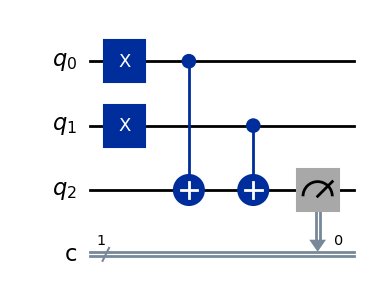

In [177]:
# Test XOR gate implementation
print("=" * 50)
print("Testing XOR Gate")
print("=" * 50)

qc_xor = QuantumCircuit(3, 1)
qc_xor.x(0)  # Input a = 1
qc_xor.x(1)  # Input b = 1

# XOR implementation: Two CNOTs
qc_xor.cx(0, 2)
qc_xor.cx(1, 2)

qc_xor.measure(2, 0)
print(qc_xor)
print()

result_xor = simulator.run(transpile(qc_xor, simulator), shots=1).result()
print(f"XOR(1,1) = {list(result_xor.get_counts().keys())[0]} (expected: 0)")
print()
qc_xor.draw('mpl')

Testing NAND Gate
     ┌───┐             
q_0: ┤ X ├──■──────────
     ├───┤  │          
q_1: ┤ X ├──■──────────
     └───┘┌─┴─┐┌───┐┌─┐
q_2: ─────┤ X ├┤ X ├┤M├
          └───┘└───┘└╥┘
c: 1/════════════════╩═
                     0 

NAND(1,1) = 0 (expected: 0)

NAND(1,1) = 0 (expected: 0)



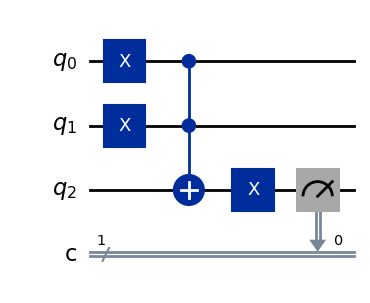

In [178]:
# Test NAND gate implementation
print("=" * 50)
print("Testing NAND Gate")
print("=" * 50)

qc_nand = QuantumCircuit(3, 1)
qc_nand.x(0)  # Input a = 1
qc_nand.x(1)  # Input b = 1

# NAND implementation: Toffoli + X
qc_nand.ccx(0, 1, 2)
qc_nand.x(2)

qc_nand.measure(2, 0)
print(qc_nand)
print()

result_nand = simulator.run(transpile(qc_nand, simulator), shots=1).result()
print(f"NAND(1,1) = {list(result_nand.get_counts().keys())[0]} (expected: 0)")
print()
qc_nand.draw('mpl')

In [179]:
# Comprehensive test of all bonus gates
print("=" * 50)
print("Comprehensive Test - All Extended Gates")
print("=" * 50)
print("\nTruth Tables:\n")

test_inputs = [(0,0), (0,1), (1,0), (1,1)]

print("OR Gate Truth Table:")
print("a | b | OR(a,b)")
print("-" * 20)
for a, b in test_inputs:
    qc = QuantumCircuit(3, 1)
    if a: qc.x(0)
    if b: qc.x(1)
    qc.x(0); qc.x(1)
    qc.ccx(0, 1, 2)
    qc.x(0); qc.x(1); qc.x(2)
    qc.measure(2, 0)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    output = list(result.get_counts().keys())[0]
    print(f"{a} | {b} | {output}")

print("\nXOR Gate Truth Table:")
print("a | b | XOR(a,b)")
print("-" * 20)
for a, b in test_inputs:
    qc = QuantumCircuit(3, 1)
    if a: qc.x(0)
    if b: qc.x(1)
    qc.cx(0, 2)
    qc.cx(1, 2)
    qc.measure(2, 0)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    output = list(result.get_counts().keys())[0]
    print(f"{a} | {b} | {output}")

print("\nNAND Gate Truth Table:")
print("a | b | NAND(a,b)")
print("-" * 20)
for a, b in test_inputs:
    qc = QuantumCircuit(3, 1)
    if a: qc.x(0)
    if b: qc.x(1)
    qc.ccx(0, 1, 2)
    qc.x(2)
    qc.measure(2, 0)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    output = list(result.get_counts().keys())[0]
    print(f"{a} | {b} | {output}")

Comprehensive Test - All Extended Gates

Truth Tables:

OR Gate Truth Table:
a | b | OR(a,b)
--------------------
0 | 0 | 0
0 | 1 | 1
1 | 0 | 1
0 | 1 | 1
1 | 0 | 1
1 | 1 | 1

XOR Gate Truth Table:
a | b | XOR(a,b)
--------------------
0 | 0 | 0
1 | 1 | 1

XOR Gate Truth Table:
a | b | XOR(a,b)
--------------------
0 | 0 | 0
0 | 1 | 1
1 | 0 | 1
0 | 1 | 1
1 | 0 | 1
1 | 1 | 0

NAND Gate Truth Table:
a | b | NAND(a,b)
--------------------
0 | 0 | 1
0 | 1 | 1
1 | 1 | 0

NAND Gate Truth Table:
a | b | NAND(a,b)
--------------------
0 | 0 | 1
0 | 1 | 1
1 | 0 | 1
1 | 1 | 0
1 | 0 | 1
1 | 1 | 0
